importar bibliotecas

In [79]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.vector_ar.var_model import VARProcess
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.vector_ar.vecm import VECM
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import  plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import pacf
from statsmodels.tsa.seasonal import seasonal_decompose

importar base de dados

In [80]:
df = pd.read_csv("df_cont_pub_VAR.csv", sep=";")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   data                193 non-null    str  
 1   brent               193 non-null    str  
 2   cambio              193 non-null    str  
 3   resultado_primario  193 non-null    str  
 4   selic_mensal        193 non-null    str  
 5   ibc_br              193 non-null    str  
dtypes: str(6)
memory usage: 15.7 KB


Trata-se os dados, agora.

In [81]:
df['data'] = pd.to_datetime(df['data'], dayfirst=True)

df.head()

C:\Users\marci\AppData\Local\Temp\ipykernel_29244\2049216916.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['data'] = pd.to_datetime(df['data'], dayfirst=True)


,data,brent,cambio,resultado_primario,selic_mensal,ibc_br
0,2010-01-01,"72,75","1,874","4,68","0,66","93,48326"
1,2010-02-01,77,"1,8102","-0,25","0,59","94,38038"
2,2010-03-01,"80,37","1,7802","-1,26","0,76","95,30077"
3,2010-04-01,"86,72","1,7298","5,38","0,67","95,75688"
4,2010-05-01,"73,56","1,8159","-0,45","0,75","95,04524"


In [82]:
df = df.sort_values('data')
df =df.set_index('data')
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 193 entries, 2010-01-01 to 2026-01-01
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   brent               193 non-null    str  
 1   cambio              193 non-null    str  
 2   resultado_primario  193 non-null    str  
 3   selic_mensal        193 non-null    str  
 4   ibc_br              193 non-null    str  
dtypes: str(5)
memory usage: 14.3 KB


In [83]:
df['ibc_br'] = (df['ibc_br'].str.replace(',', '.', regex=False).astype(float))
df['selic_mensal'] = (df['selic_mensal'].str.replace(',', '.', regex=False).astype(float))
df['brent'] = (df['brent'].str.replace(',', '.', regex=False).astype(float))
df['cambio'] = (df['cambio'].str.replace(',', '.', regex=False).astype(float))
df['resultado_primario'] = (df['resultado_primario'].str.replace(',', '.', regex=False).astype(float))
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 193 entries, 2010-01-01 to 2026-01-01
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   brent               193 non-null    float64
 1   cambio              193 non-null    float64
 2   resultado_primario  193 non-null    float64
 3   selic_mensal        193 non-null    float64
 4   ibc_br              193 non-null    float64
dtypes: float64(5)
memory usage: 9.0 KB


Transforma-se brent, cambio e ibc_br em log. As séries resultado_primario (tem valores negativos) e selic (já está em taxa acumulada no mês) não serão transformadas em log.

In [84]:
df["log_ibc_br"] = np.log(df["ibc_br"])
df["log_brent"] = np.log(df['brent'])
df["log_cambio"] = np.log(df['cambio'])

In [85]:
df.head()

,brent,cambio,resultado_primario,selic_mensal,ibc_br,log_ibc_br,log_brent,log_cambio
data,,,,,,,,
2010-01-01,72.75,1.8740,4.68,0.66,93.48326,4.537782,4.287029,0.628075
2010-02-01,77.00,1.8102,-0.25,0.59,94.38038,4.547333,4.343805,0.593437
2010-03-01,80.37,1.7802,-1.26,0.76,95.30077,4.557038,4.386641,0.576726
2010-04-01,86.72,1.7298,5.38,0.67,95.75688,4.561812,4.462685,0.548006
2010-05-01,73.56,1.8159,-0.45,0.75,95.04524,4.554353,4.298101,0.596581


Primeiro passo é desazonalizar a série do resultado_primario.

In [86]:
df.index = pd.to_datetime(df.index)
y = df['resultado_primario']
dummies = pd.get_dummies(df.index.month, prefix='mes', drop_first=True)
dummies.index = df.index
dummies = dummies.astype(int)
X = sm.add_constant(dummies)
modelo = sm.OLS(y, X, missing='drop').fit()

df['resultado_primario_sa'] = modelo.resid + y.mean()


Vamos analisar cada uma das variáveis (brent, cambio, resultado_primario, ibc_br e selic) e ver se são estacionárias e/ou cointegradas, para a escolha do modelo adequado de estudo (VAR ou VECM< por exemplo). Começa-se pela variável brent, representativa da atividade econômica.

<Axes: xlabel='data'>

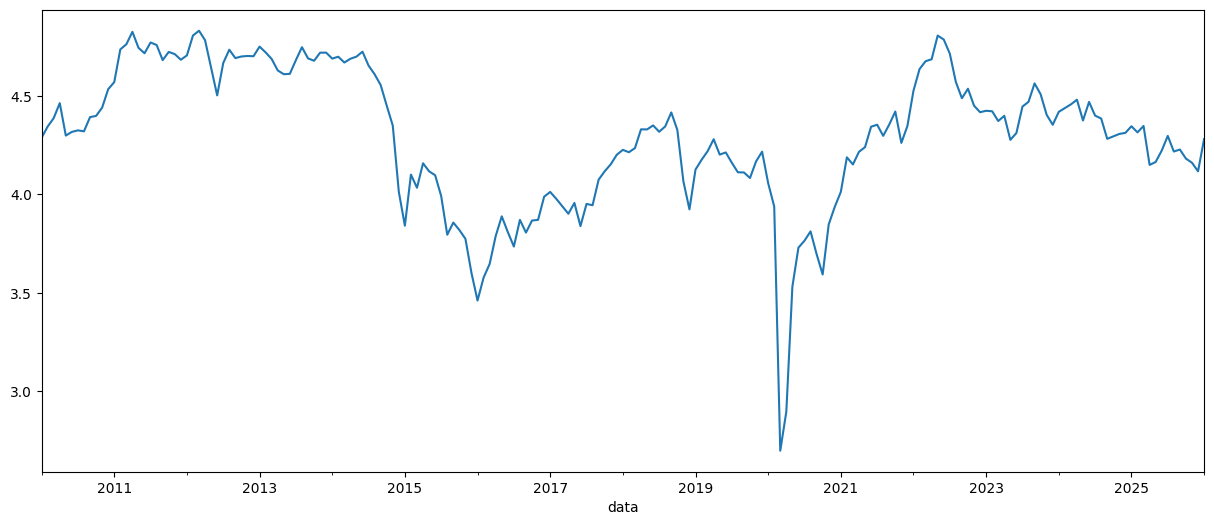

In [87]:
df['log_brent'].plot(figsize=(15,6))

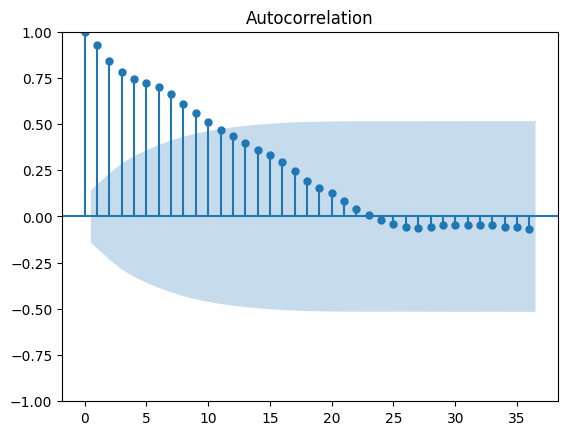

In [88]:
plot_acf(df['log_brent'], lags=36)
plt.show()

In [89]:
resultado = adfuller(df['log_brent'].dropna())
print('Estatística ADF:', resultado[0])
print('p-value:', resultado[1])
print('Número de lags usados:', resultado[2])
print('Número de observações:', resultado [3])

print('\nValores Críticos:')
for chave, valor in resultado[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -1.9558464389995005
p-value: 0.30626192253915685
Número de lags usados: 4
Número de observações: 188

Valores Críticos:
1%: -3.465620397124192
5%: -2.8770397560752436
10%: -2.5750324547306476


In [90]:
resultado2 = kpss(df['log_brent'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado2[0])
print('p-value:', resultado2[1])
print('Lags usados:', resultado2[2])
print('\nValores críticos:')
for chave, valor in resultado2[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.37135104916141515
p-value: 0.08950385812007967
Lags usados: 9

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


Tanto pelo correlograma, quanto pelo teste ADF e pelo KPSS (em nível de 5%), deduz-se que a série brent não é estacionária. Logo, diferencia-se a série uma vez e testa-se, outra vez, a estacionariedade dos dados. Dessa vez, da série ibc_br I(1).

In [91]:
serie_diff = df['log_brent'].diff().dropna()
serie_diff

data
2010-02-01    0.056777
2010-03-01    0.042836
2010-04-01    0.076044
2010-05-01   -0.164583
2010-06-01    0.018586
                ...   
2025-09-01    0.010121
2025-10-01   -0.045992
2025-11-01   -0.021157
2025-12-01   -0.043381
2026-01-01    0.163537
Name: log_brent, Length: 192, dtype: float64

In [92]:
resultado3 = adfuller(serie_diff)
print('Estatística ADF:', resultado3[0])
print('p-value:', resultado3[1])
print('Número de lags usados:', resultado3[2])
print('Número de observações:', resultado3 [3])

print('\nValores Críticos:')
for chave, valor in resultado3[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -8.976187636930804
p-value: 7.521032270514883e-15
Número de lags usados: 3
Número de observações: 188

Valores Críticos:
1%: -3.465620397124192
5%: -2.8770397560752436
10%: -2.5750324547306476


In [93]:
resultado4 = kpss(serie_diff, regression= 'c')

print("Estatística KPSS:", resultado4[0])
print('p-value:', resultado4[1])
print('Lags usados:', resultado4[2])
print('\nValores críticos:')
for chave, valor in resultado4[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.056027245163949295
p-value: 0.1
Lags usados: 12

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\2404246618.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado4 = kpss(serie_diff, regression= 'c')


Tanto pelo teste ADF quanto pelo teste KPSS aceita-se a estacionariedade da série log_brent diferençada uma vez I(1).

Passa-se, agora, ao estudo da log_cambio.

<Axes: xlabel='data'>

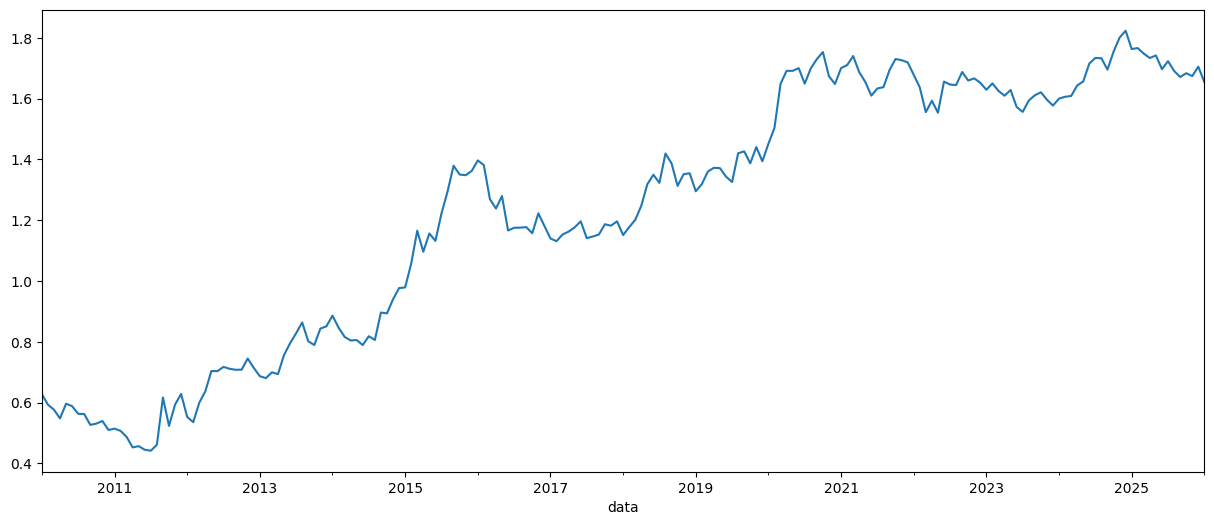

In [94]:
df['log_cambio'].plot(figsize=(15,6))

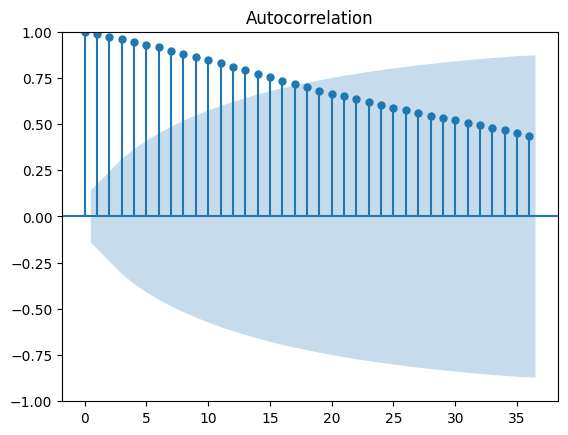

In [95]:
plot_acf(df['log_cambio'], lags=36)
plt.show()

In [96]:
resultado5 = adfuller(df['log_cambio'].dropna())
print('Estatística ADF:', resultado5[0])
print('p-value:', resultado5[1])
print('Número de lags usados:', resultado5[2])
print('Número de observações:', resultado5[3])

print('\nValores Críticos:')
for chave, valor in resultado5[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -1.0667032000086967
p-value: 0.7281660446718241
Número de lags usados: 0
Número de observações: 192

Valores Críticos:
1%: -3.4648754262570978
5%: -2.876714157488788
10%: -2.574858699001736


In [97]:
resultado6 = kpss(df['log_cambio'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado6[0])
print('p-value:', resultado6[1])
print('Lags usados:', resultado6[2])
print('\nValores críticos:')
for chave, valor in resultado6[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 1.8878692233295444
p-value: 0.01
Lags usados: 9

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\4248874414.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  resultado6 = kpss(df['log_cambio'].dropna(), regression= 'c')


Tanto pelo correlograma, quanto pelo teste ADF e pelo KPSS, deduz-se que a série log_brent não é estacionária. Logo, diferencia-se a série uma vez e testa-se, outra vez, a estacionariedade dos dados. Dessa vez, da série log_brent I(1).

In [98]:
serie_diff_2 = df['log_cambio'].diff().dropna()
serie_diff_2

data
2010-02-01   -0.034638
2010-03-01   -0.016712
2010-04-01   -0.028720
2010-05-01    0.048575
2010-06-01   -0.008406
                ...   
2025-09-01   -0.020068
2025-10-01    0.012279
2025-11-01   -0.009424
2025-12-01    0.031124
2026-01-01   -0.050760
Name: log_cambio, Length: 192, dtype: float64

In [99]:
resultado7 = adfuller(serie_diff_2)
print('Estatística ADF:', resultado7[0])
print('p-value:', resultado7[1])
print('Número de lags usados:', resultado7[2])
print('Número de observações:', resultado7[3])

print('\nValores Críticos:')
for chave, valor in resultado7[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -14.41281453885114
p-value: 8.151213026345673e-27
Número de lags usados: 0
Número de observações: 191

Valores Críticos:
1%: -3.465058702600837
5%: -2.8767942675230356
10%: -2.5749014492475535


In [100]:
resultado8 = kpss(serie_diff_2, regression= 'c')

print("Estatística KPSS:", resultado8[0])
print('p-value:', resultado8[1])
print('Lags usados:', resultado8[2])
print('\nValores críticos:')
for chave, valor in resultado8[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.10687016294315502
p-value: 0.1
Lags usados: 1

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\3063396531.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado8 = kpss(serie_diff_2, regression= 'c')


Tanto pelo teste ADF quanto pelo teste KPSS aceita-se a estacionariedade da série log_cambio diferençada uma vez I(1).

Passa-se, agora, ao estudo da resultado_primario..

<Axes: xlabel='data'>

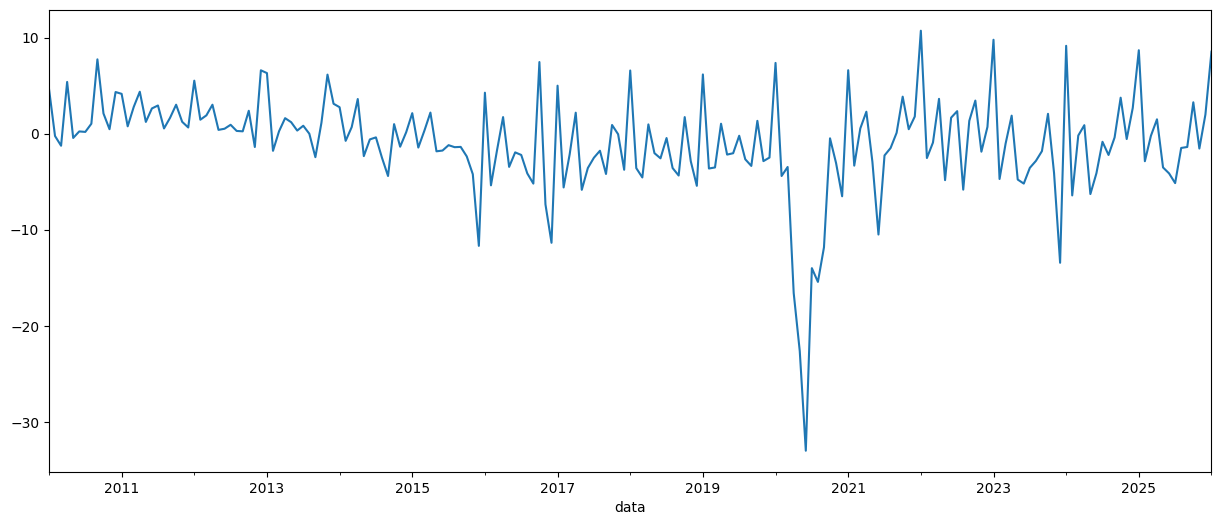

In [101]:
df['resultado_primario'].plot(figsize=(15,6))

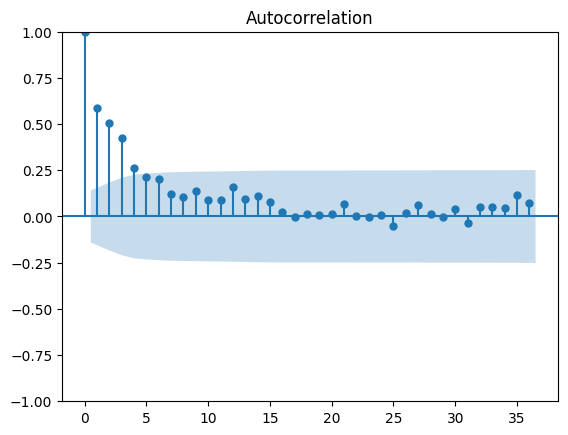

In [102]:
plot_acf(df['resultado_primario_sa'], lags=36)
plt.show()

In [103]:
resultado9 = adfuller(df['resultado_primario_sa'].dropna())
print('Estatística ADF:', resultado9[0])
print('p-value:', resultado9[1])
print('Número de lags usados:', resultado9[2])
print('Número de observações:', resultado9[3])

print('\nValores Críticos:')
for chave, valor in resultado9[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -4.793757657350547
p-value: 5.5901228726484325e-05
Número de lags usados: 1
Número de observações: 191

Valores Críticos:
1%: -3.465058702600837
5%: -2.8767942675230356
10%: -2.5749014492475535


In [104]:
resultado10 = kpss(df['resultado_primario_sa'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado10[0])
print('p-value:', resultado10[1])
print('Lags usados:', resultado10[2])
print('\nValores críticos:')
for chave, valor in resultado10[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.4734254342968868
p-value: 0.04765192921241288
Lags usados: 8

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


In [105]:
resultado11 = kpss(df['resultado_primario'].dropna(), regression= 'ct')

print("Estatística KPSS:", resultado11[0])
print('p-value:', resultado11[1])
print('Lags usados:', resultado11[2])
print('\nValores críticos:')
for chave, valor in resultado11[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.19668768091427621
p-value: 0.017242119657146417
Lags usados: 8

Valores críticos:
10%: 0.119
5%: 0.146
2.5%: 0.176
1%: 0.216


O correlograma indica possibilidade de a série resultado_primario ser estacionária. O ADF a 10% reforça a suspeita de I(0). Não obstante, o teste KPSS com constante e o teste KPSS com constante + tendência (ct) mostram que a série resultado_primario não é estacionária. Testa-se a possibilidade de ser I(1). Antes, diferencia-se a série resultado_primario.

In [106]:
serie_diff_3 = df['resultado_primario_sa'].diff().dropna()
serie_diff_3

data
2010-02-01    4.222537
2010-03-01   -3.004375
2010-04-01    4.626875
2010-05-01   -0.833750
2010-06-01    0.915625
                ...   
2025-09-01   -0.762500
2025-10-01    0.633750
2025-11-01   -1.216875
2025-12-01    4.147500
2026-01-01   -1.873787
Name: resultado_primario_sa, Length: 192, dtype: float64

In [107]:
resultado12 = adfuller(serie_diff_3)
print('Estatística ADF:', resultado12[0])
print('p-value:', resultado12[1])
print('Número de lags usados:', resultado12[2])
print('Número de observações:', resultado12 [3])

print('\nValores Críticos:')
for chave, valor in resultado12[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -8.52053918720446
p-value: 1.1037552740588202e-13
Número de lags usados: 4
Número de observações: 187

Valores Críticos:
1%: -3.465811691080702
5%: -2.877123351472649
10%: -2.5750770662586864


In [108]:
resultado13 = kpss(serie_diff_3, regression= 'c')

print("Estatística KPSS:", resultado13[0])
print('p-value:', resultado13[1])
print('Lags usados:', resultado13[2])
print('\nValores críticos:')
for chave, valor in resultado13[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.01969525780510917
p-value: 0.1
Lags usados: 4

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\2835853339.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado13 = kpss(serie_diff_3, regression= 'c')


Agora, ambos os testes indicam que a série resultado_primario é I(1).

Passa-se ao estudo da série selic_mensal.

<Axes: xlabel='data'>

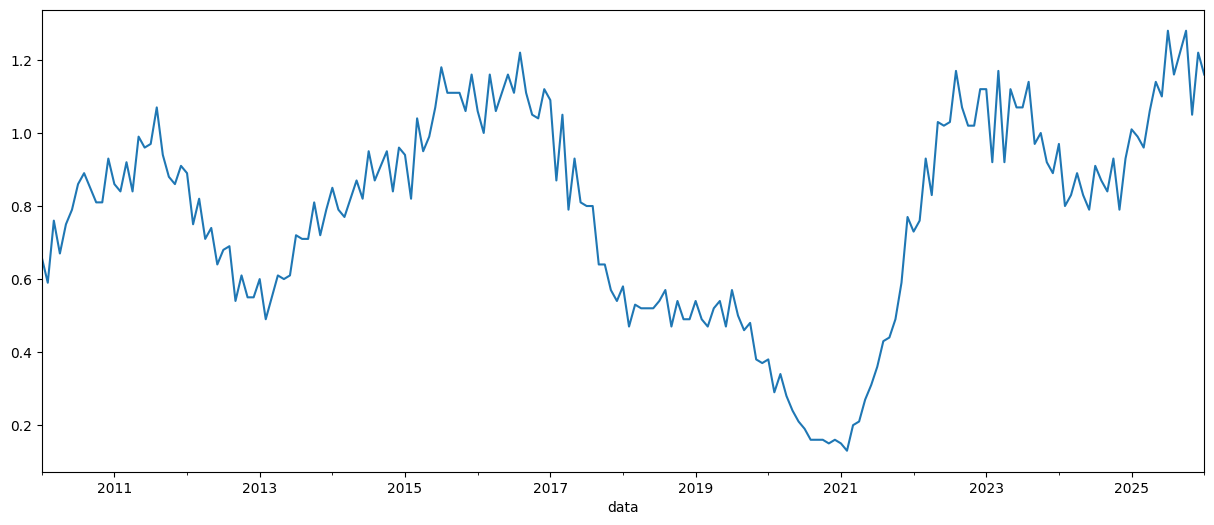

In [109]:
df['selic_mensal'].plot(figsize=(15,6))

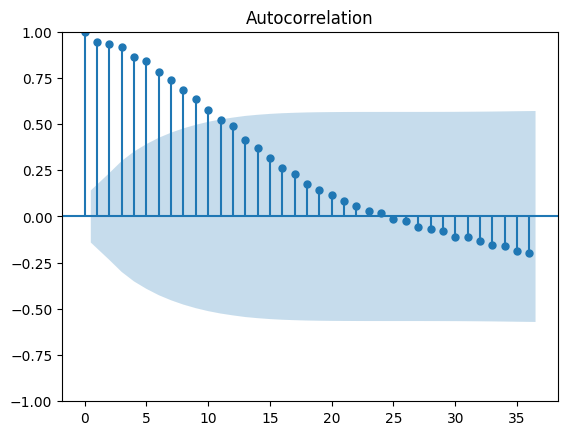

In [110]:
plot_acf(df['selic_mensal'], lags=36)
plt.show()

In [111]:
resultado14 = adfuller(df['selic_mensal'].dropna())
print('Estatística ADF:', resultado14[0])
print('p-value:', resultado14[1])
print('Número de lags usados:', resultado14[2])
print('Número de observações:', resultado14[3])

print('\nValores Críticos:')
for chave, valor in resultado14[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -2.4540358106444065
p-value: 0.12706206872505676
Número de lags usados: 15
Número de observações: 177

Valores Críticos:
1%: -3.467845319799907
5%: -2.878011745497439
10%: -2.575551186759871


In [112]:
resultado15 = kpss(df['selic_mensal'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado15[0])
print('p-value:', resultado15[1])
print('Lags usados:', resultado15[2])
print('\nValores críticos:')
for chave, valor in resultado15[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.1946568715121614
p-value: 0.1
Lags usados: 9

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\738413135.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado15 = kpss(df['selic_mensal'].dropna(), regression= 'c')


A série selic_mensal, pelo correlograma, tem suspeita de presença de raiz unitária. O teste ADF a 10% reforça essa suspeita. Não obstante, o teste KPSS indica que os dados são estacionários. Dado a situação, diferencia-se a série selic_mensal e testa-se o ADF e o KPSS para a série diferenciada.

In [113]:
serie_diff_4 = df['selic_mensal'].diff().dropna()
serie_diff_4

data
2010-02-01   -0.07
2010-03-01    0.17
2010-04-01   -0.09
2010-05-01    0.08
2010-06-01    0.04
              ... 
2025-09-01    0.06
2025-10-01    0.06
2025-11-01   -0.23
2025-12-01    0.17
2026-01-01   -0.06
Name: selic_mensal, Length: 192, dtype: float64

In [114]:
resultado16 = adfuller(serie_diff_4)
print('Estatística ADF:', resultado16[0])
print('p-value:', resultado16[1])
print('Número de lags usados:', resultado16[2])
print('Número de observações:', resultado16[3])

print('\nValores Críticos:')
for chave, valor in resultado16[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -4.3002737290544575
p-value: 0.00044372775956643567
Número de lags usados: 15
Número de observações: 176

Valores Críticos:
1%: -3.4680615871598537
5%: -2.8781061899535128
10%: -2.5756015922004134


In [115]:
resultado17 = kpss(serie_diff_4, regression= 'c')

print("Estatística KPSS:", resultado17[0])
print('p-value:', resultado17[1])
print('Lags usados:', resultado17[2])
print('\nValores críticos:')
for chave, valor in resultado17[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.10713979554004865
p-value: 0.1
Lags usados: 8

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\3516441038.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado17 = kpss(serie_diff_4, regression= 'c')


Confirma-se que a série selic_mensal é I(1). Passa-se, agora, para a última variável, log_ibc_br.

<Axes: xlabel='data'>

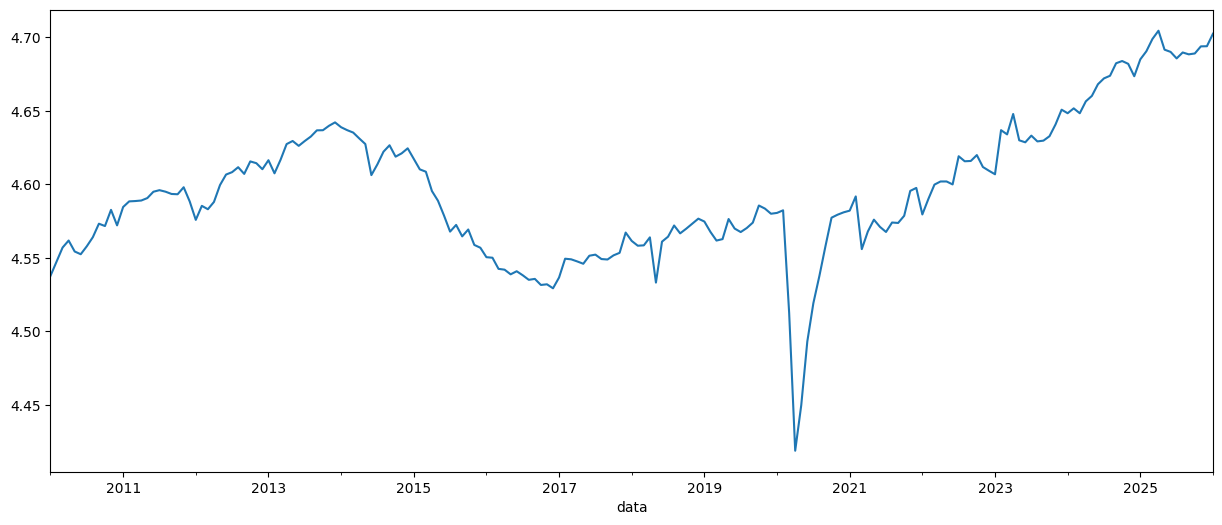

In [116]:
df['log_ibc_br'].plot(figsize=(15,6))

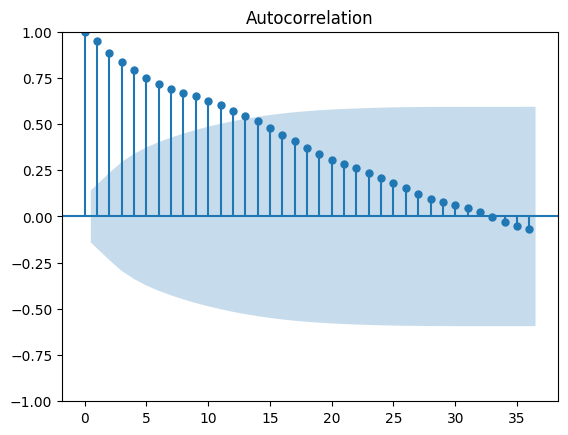

In [117]:
plot_acf(df['log_ibc_br'], lags=36)
plt.show()

In [118]:
resultado18 = adfuller(df['log_ibc_br'].dropna())
print('Estatística ADF:', resultado18[0])
print('p-value:', resultado18[1])
print('Número de lags usados:', resultado18[2])
print('Número de observações:', resultado18[3])

print('\nValores Críticos:')
for chave, valor in resultado18[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -1.3234137555169314
p-value: 0.6183935895789382
Número de lags usados: 2
Número de observações: 190

Valores Críticos:
1%: -3.4652439354133255
5%: -2.8768752281673717
10%: -2.574944653739612


In [119]:
resultado19 = kpss(df['log_ibc_br'].dropna(), regression= 'c')

print("Estatística KPSS:", resultado19[0])
print('p-value:', resultado19[1])
print('Lags usados:', resultado19[2])
print('\nValores críticos:')
for chave, valor in resultado19[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.5724501683882542
p-value: 0.025349061173816603
Lags usados: 9

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


Tanto pelo correlograma, quanto pelo Teste ADF e pelo Teste KPSS a indicação é de que a série log_ibc_br possui raiz unitária. Assim, diferencia-se a série e depois aplica-se os testes ADF e KPSS.

In [120]:
serie_diff_5 = df['log_ibc_br'].diff().dropna()
serie_diff_5

data
2010-02-01    0.009551
2010-03-01    0.009705
2010-04-01    0.004775
2010-05-01   -0.007459
2010-06-01   -0.001859
                ...   
2025-09-01   -0.001274
2025-10-01    0.000592
2025-11-01    0.004831
2025-12-01    0.000103
2026-01-01    0.008520
Name: log_ibc_br, Length: 192, dtype: float64

In [121]:
resultado20 = adfuller(serie_diff_5)
print('Estatística ADF:', resultado20[0])
print('p-value:', resultado20[1])
print('Número de lags usados:', resultado20[2])
print('Número de observações:', resultado20[3])

print('\nValores Críticos:')
for chave, valor in resultado20[4].items():
    print(f'{chave}: {valor}')

Estatística ADF: -7.311853506780988
p-value: 1.2583149704543765e-10
Número de lags usados: 5
Número de observações: 186

Valores Críticos:
1%: -3.466005071659723
5%: -2.8772078537639385
10%: -2.5751221620996647


In [122]:
resultado21 = kpss(serie_diff_5, regression= 'c')

print("Estatística KPSS:", resultado21[0])
print('p-value:', resultado21[1])
print('Lags usados:', resultado21[2])
print('\nValores críticos:')
for chave, valor in resultado21[3].items():
    print(f'{chave}: {valor}')

Estatística KPSS: 0.12681432595089534
p-value: 0.1
Lags usados: 6

Valores críticos:
10%: 0.347
5%: 0.463
2.5%: 0.574
1%: 0.739


C:\Users\marci\AppData\Local\Temp\ipykernel_29244\2943945934.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  resultado21 = kpss(serie_diff_5, regression= 'c')


Tanto pelo Teste ADF, quanto pelo Teste KPSS, desduz-se que a série log_ibc_br é I(1).

Como todas as séries são I(1), testa-se a possibilidade delas serem cointegradas.

In [123]:
df_coint = df[['log_brent', 'log_cambio', 'resultado_primario', 'selic_mensal', 'log_ibc_br']].dropna()
modelo_var = VAR(df_coint)
selecao = modelo_var.select_order(maxlags=12)

print(selecao.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -10.40      -10.32   3.032e-05      -10.37
1       -21.02      -20.49   7.413e-10      -20.81
2       -21.58     -20.61*   4.244e-10     -21.19*
3       -21.63      -20.22   4.041e-10      -21.06
4      -21.83*      -19.97  3.328e-10*      -21.08
5       -21.79      -19.49   3.469e-10      -20.86
6       -21.69      -18.95   3.866e-10      -20.58
7       -21.61      -18.43   4.239e-10      -20.32
8       -21.50      -17.88   4.788e-10      -20.03
9       -21.54      -17.47   4.683e-10      -19.89
10      -21.52      -17.02   4.855e-10      -19.70
11      -21.42      -16.47   5.541e-10      -19.41
12      -21.65      -16.26   4.540e-10      -19.46
--------------------------------------------------


c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Akayke (AIC) e FPE indicam 4 lags. Schwarz (BIC) e Hannan_Quinn (HQIC) indicam 2 lags. Testa-se, primeiro, a possibilidade de 2 lags no Teste de Johansen (k_ar_diff = 1; logo VAR(2)).

In [124]:
resultado22 = coint_johansen(df_coint, det_order=1, k_ar_diff=1)

resultado22.lr1


array([129.5061842 ,  51.95518289,  19.80517547,   7.52006311,
         1.58007334])

In [125]:
resultado22.cvt

array([[75.1027, 79.3422, 87.7748],
       [51.6492, 55.2459, 62.5202],
       [32.0645, 35.0116, 41.0815],
       [16.1619, 18.3985, 23.1485],
       [ 2.7055,  3.8415,  6.6349]])

Pelo teste de Johansen com 2 lags (VAR(2)) e a presença de uma constante (det_order =1), observa-se 1 vetor de cointegração (rank = 1). Isso significa que existe uma combinação linear independente das 5 séries de estudo.

Testa-se, agora, um VAR(4) para o teste de Johansen.

In [126]:
resultado23 = coint_johansen(df_coint, det_order=1, k_ar_diff=3)

resultado23.lr1


array([107.21140245,  47.94615338,  27.00551518,  10.57204181,
         1.31699618])

In [127]:
resultado23.cvt

array([[75.1027, 79.3422, 87.7748],
       [51.6492, 55.2459, 62.5202],
       [32.0645, 35.0116, 41.0815],
       [16.1619, 18.3985, 23.1485],
       [ 2.7055,  3.8415,  6.6349]])

O teste de Johansen com 4 lags (VAR(4)) indica apenas uma única combinação linear entre as variáveis. Desse modo, a opção é usar o VAR(2).

Como existe 1 relação de equilíbrio estacionária no VAR(2), isso justifica o uso do VECM em vez do VAR em diferenças, o qual jogaria fora essa informação de longo prazo. Passa-se, assim, ao VECM.

In [128]:
df["dummy_2020"] = (df.index.year == 2020).astype(int)

In [129]:
dados = df[['log_brent', 'log_cambio', 'log_ibc_br', 'selic_mensal', 'resultado_primario_sa']]

exog = df[["dummy_2020"]]

vecm = VECM(dados, exog=exog, k_ar_diff=1, coint_rank=1, deterministic="ci")

result = vecm.fit()
print(result.summary())

  Det. terms outside the coint. relation & lagged endog. parameters for equation log_brent  
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
exog1                       -0.0651      0.045     -1.461      0.144      -0.153       0.022
L1.log_brent                 0.1181      0.077      1.534      0.125      -0.033       0.269
L1.log_cambio               -0.1078      0.227     -0.476      0.634      -0.552       0.336
L1.log_ibc_br               -3.3494      0.806     -4.153      0.000      -4.930      -1.769
L1.selic_mensal              0.0475      0.103      0.460      0.645      -0.155       0.250
L1.resultado_primario_sa     0.0025      0.003      0.830      0.406      -0.003       0.009
 Det. terms outside the coint. relation & lagged endog. parameters for equation log_cambio  
                               coef    std err          z      P>|z|  

c:\Users\marci\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [130]:
print(result.alpha)


[[ 2.41828335e-02]
 [ 6.20157801e-04]
 [ 3.62933687e-03]
 [-1.99729413e-02]
 [ 2.17852504e+00]]


In [131]:
print(result.beta)

[[ 1.        ]
 [-0.56546358]
 [ 2.22357825]
 [-0.04974387]
 [-0.30713543]]


In [132]:
pd.DataFrame(result.alpha, index=dados.columns, columns=['ajuste.relacao_1'])

,ajuste.relacao_1
log_brent,0.024183
log_cambio,0.000620
log_ibc_br,0.003629
selic_mensal,-0.019973
resultado_primario_sa,2.178525


In [133]:
pd.DataFrame(result.beta, index=dados.columns, columns=['relacao_logo_prazo_1'])

,relacao_logo_prazo_1
log_brent,1.000000
log_cambio,-0.565464
log_ibc_br,2.223578
selic_mensal,-0.049744
resultado_primario_sa,-0.307135


As variáveis brent, cambio e atividade econômica (ibc_br) estão em log, enquanto a selic está em porcentagem e o resultado_primario_sa está dividido pelo PIB (Tornando-se uma taxa do PIB) e dessazonalizado. Assim, no resultado alpha, vê-se que o resultado_primario absorve o ajuste, uma vez que está em nível, sem estar em log. De modo que a variável resultado_primario torna-se de difícil interpretação. Assim, o modelo não está errado, mas os alphas não são comparáveis entre si. Os sinais dos alphas são o que importa.

Lembrando que tem-se o Johansen com rank 1, o que torna o VECM adequado. O beta mostra uma relação de longo prazo (uma coluna) e o alpha mostra quais variáveis ajustam quando essas relações se desviam (termo de correção de erro).

Tem-se no Beta:

1) log_brent - 0.565 log_cambio - 0.307 resultado_primario_sa - 0.050 selic_mensal + 0.2.224 log_ibc_br

A equação 1 é a equação de equilíbrio. Ela indica que existe uma combinação das variáveis brent, cambio, resultado_primario, selic e ibc_br que não explode no longo prazo. Em outras palavras, estas variáveis estão amarradas no equilíbrio de longo prazo.

Vale ressaltar que, pelo que se vê em alpha, a variável principal que ajusta o sistema é resultado_primario_sa.

Estima-se a seguir a Função Impulso-Resposta (IRF).

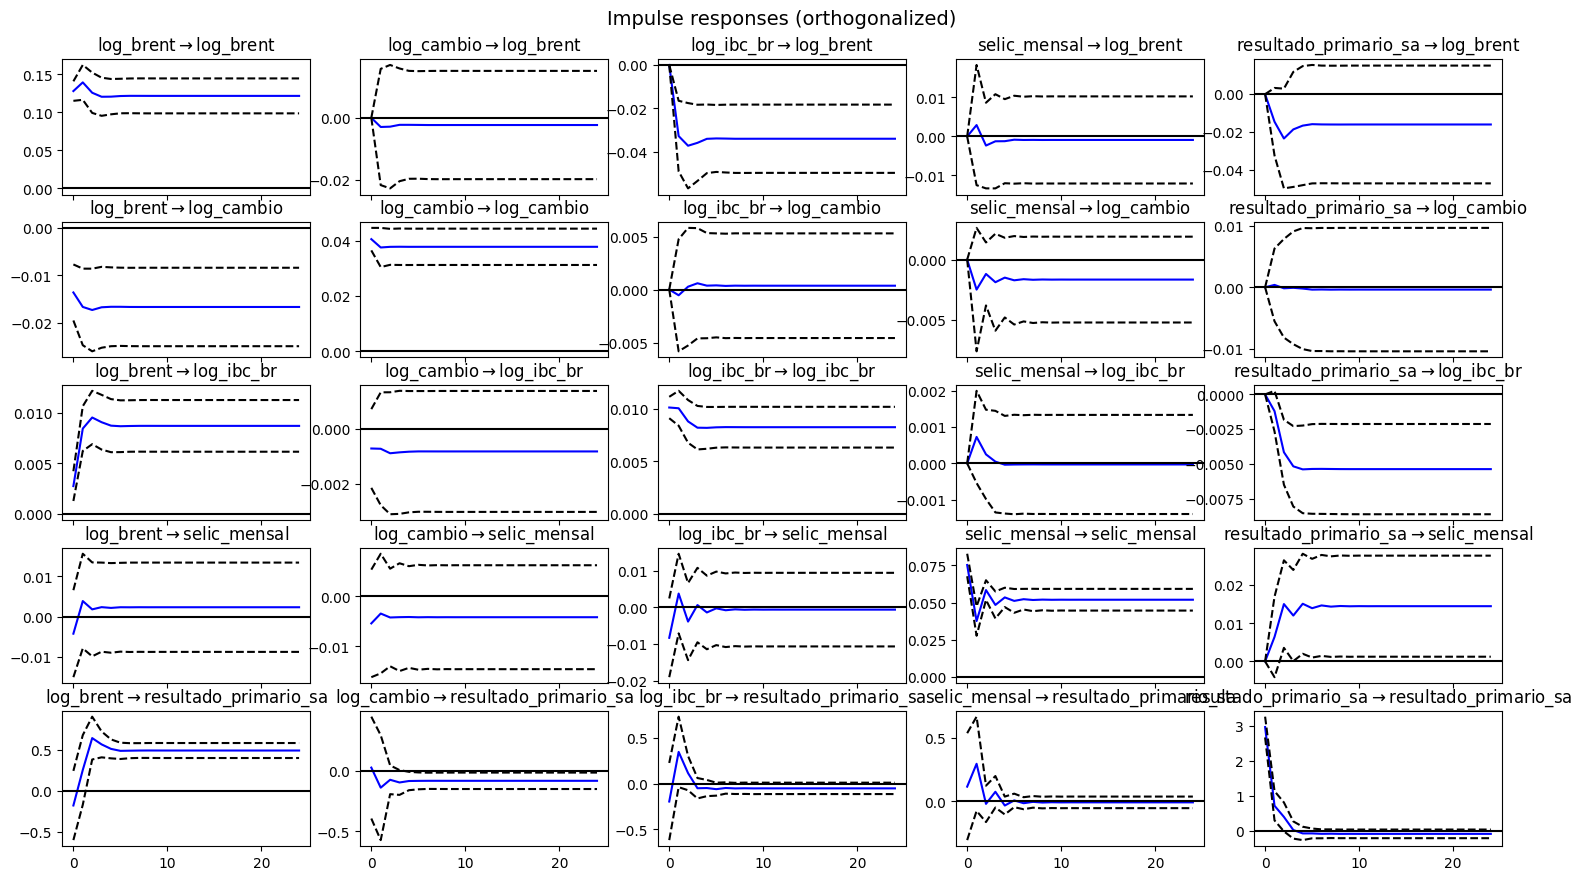

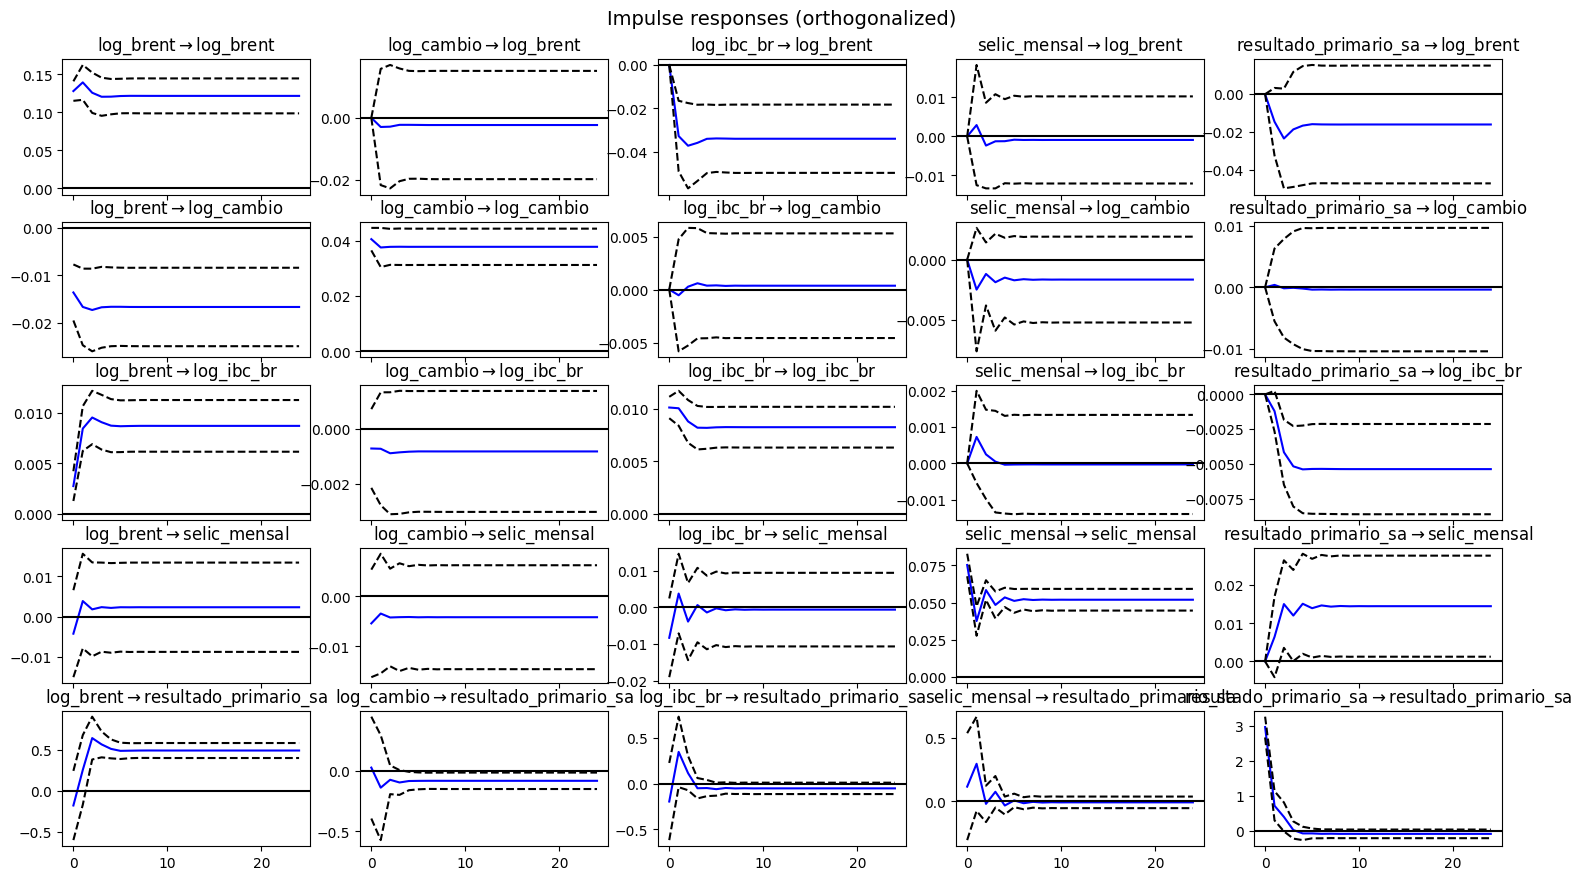

In [134]:
irf = result.irf(periods=24)
irf.plot(orth=True, figsize=(16,9))

Para quantificar o impacto temos irf_values[tempo, variável_resposta, variável_choque]

Nossa ordem é:

0 - log_brent,
1- log_cambio,
2- log_ibc_br,
3 - selic_mensal,
4 - resultado_primario_sa.

Então, caso tenha-se irf_values[:, 1, 4] está-se medindo, ao logo de todos os 24 meses (: significa todo o período observado, o que no caso presente corresponde a 24 meses), o log_cambio sofre um choque da selic_mensal (ou seja, o comando dá como resultado a resposta do câmbio a um choque na selic).

In [135]:
irf_values = irf.irfs

In [136]:
impacto = irf_values[:, 2, 0]

In [137]:
impacto.max()

np.float64(0.05368170618676934)

In [138]:
impacto.min()

np.float64(0.0)

In [139]:
impacto.argmax()

np.int64(2)

In [140]:
impacto.argmin()

np.int64(0)

In [141]:
dados["log_brent"].std()

np.float64(0.3535821375184303)

In [142]:
choque_brent = float(dados['log_brent'].std())
impacto_pico = float(impacto.max())

elasticidade = impacto_pico/choque_brent
impacto_10 = elasticidade*0.10

impacto_pico_pct = (np.exp(impacto_pico)-1)*100
choque_brent_pct = (np.exp(choque_brent)-1)*100
impacto_10_pct = (np.exp(impacto_10)-1)*100

print('Choque Brent de 1 dp (%):', choque_brent_pct)
print('Impacto máximo no IBC-BR (%):', impacto_pico_pct)
print('Impacto estimado para choque de 10% no brent (%):', impacto_10_pct)


Choque Brent de 1 dp (%): 42.415995911229
Impacto máximo no IBC-BR (%): 5.514870139665629
Impacto estimado para choque de 10% no brent (%): 1.5298080695213656


In [143]:
impacto_2 = irf_values[:, 4, 0]

In [144]:
impacto_2.max()

np.float64(4.701383607786499)

In [145]:
impacto_2.min()

np.float64(0.0)

In [146]:
impacto_2.argmax()

np.int64(2)

In [147]:
impacto_2.argmin()

np.int64(0)

In [148]:
choque_brent = float(dados['log_brent'].std())
impacto_pico_2 = float(impacto_2.max())

elasticidade_2 = impacto_pico_2/choque_brent
impacto_10_2 = elasticidade_2*0.10

impacto_pico_pct_2 = impacto_pico_2
choque_brent_pct_2 = (np.exp(choque_brent)-1)*100
impacto_10_pct_2 = impacto_10_2

print('Choque Brent de 1 dp (%):', choque_brent_pct)
print('Impacto máximo no Resultado Primário (%):', impacto_pico_pct_2)
print('Impacto estimado para choque de 10% no brent (p.p. do PIB):', impacto_10_pct_2)


Choque Brent de 1 dp (%): 42.415995911229
Impacto máximo no Resultado Primário (%): 4.701383607786499
Impacto estimado para choque de 10% no brent (p.p. do PIB): 1.32964398054227


In [156]:
impacto_3 = irf_values[:, 3, 0]

In [157]:
impacto_3.max()

np.float64(0.03936774409631869)

In [158]:
impacto_3.min()

np.float64(0.0)

In [159]:
impacto_3.argmax()

np.int64(2)

In [160]:
impacto_3.argmin()

np.int64(0)

In [163]:
choque_brent = float(dados['log_brent'].std())
impacto_pico_3 = float(impacto_3.max())

elasticidade_3 = impacto_pico_3/choque_brent
impacto_10_3 = elasticidade_3*0.10

impacto_pico_pct_3 = impacto_pico_3
choque_brent_pct_3 = (np.exp(choque_brent)-1)*100
impacto_10_pct_3 = impacto_10_3

print('Choque Brent de 1 dp (%):', choque_brent_pct_3)
print('Impacto máximo na Selic (p.p.):', impacto_pico_pct_3)
print('Impacto estimado para choque de 10% no brent (p.p.):', impacto_10_pct_3)


Choque Brent de 1 dp (%): 42.415995911229
Impacto máximo na Selic (p.p.): 0.03936774409631869
Impacto estimado para choque de 10% no brent (p.p.): 0.01113397423654261


Um choque positivo de 10% no preço do Brent está associado, no modelo VECM estimado, a um aumento máximo de aproximadamente 1,53% na atividade econômica (IBC-Br), a uma variação de cerca de 1,13 ponto percentual no resultado primário e a uma resposta praticamente nula da Selic, ao redor de 0,01 ponto percentual.

Em outras palavras, no modelo, a atividade econômica responde positivamente a um choque no Brent de 10% em, no máximo, 1,53% aproximadamente. Do mesmo modo, melhora o superávit primário em aproximadamente 1,13 ponto percentual do PIB no máximo. Por fim, a Selic praticamente não é alterada, uma vez que, no máximo, sua resposta ao choque de 10% no Brent, é de apenas 0,01 ponto percentual.